In [1]:
import os, sys

nb_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(nb_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print('Using project root:', project_root)
print('First sys.path entry:', sys.path[0])

Using project root: /root/Research/RithvikDecoder/Decoder
First sys.path entry: /root/Research/RithvikDecoder/Decoder


In [2]:
import numpy as np
from scipy.sparse import csr_matrix, eye, hstack, save_npz, load_npz
import scipy.io

In [3]:
from utils.LDPC_encode import LDPCEncode
from utils.awgn_channel import AWGNChannel
from utils.find_ber import findBER
from utils.res_cluster_picker import pick_max_avg_residual_cluster, pick_max_max_residual_cluster

In [4]:
import matplotlib.pyplot as plt

In [5]:
from ldpc.bp_decoder import BpDecoder

In [6]:
H_mat_dat = scipy.io.loadmat('H.mat')
H = csr_matrix(H_mat_dat['H'])

In [7]:
decoder = BpDecoder(H)

In [8]:
n = 486 # length of message
n_frames = 100
max_iter = 30

message = np.random.randint(0, 2, (n_frames, n))
print("Message shape:", message.shape)

Message shape: (100, 486)


In [9]:
encoded_codeword = LDPCEncode(message)
print("Encoded codeword shape:", encoded_codeword.shape) 

tx_codeword = 1 - 2 * encoded_codeword 

Encoded codeword shape: (100, 648)


In [10]:
m, _ = H.shape
arr = np.arange(m)
clusters = arr.reshape(6, -1)


In [11]:
snrs = [-3, -2, -1, 0, 1, 2, 3, 4]
bers = []


for snr in snrs:
    rx_llrs = AWGNChannel(tx_codeword, snr_db=snr)
    decoded_codewords = []

    for i in range(n_frames):
        llr = rx_llrs[i, :]
        # times_cluster = [0, 0, 0, 0, 0, 0]

        decoder.reset()
        decoder.initialise_log_domain_bp(llr)
        
        for iter in range(max_iter):
            residuals = decoder.get_residuals()
            cluster_idx, scheduled_cluster = pick_max_avg_residual_cluster(residuals, clusters)

            # print(f"Scheduled cluster at iteration {iter}: {cluster_idx}")
            # times_cluster[cluster_idx] += 1

            llr = decoder.decode_cluster(scheduled_cluster)

        
        decoded_codeword = (llr < 0).astype(int)
        decoded_codewords.append(decoded_codeword)
        # print("Times each cluster was scheduled:", times_cluster)
        
    decoded_codewords = np.array(decoded_codewords)
    decoded_message = decoded_codewords[:, :n]
    ber = findBER(message, decoded_message)
    bers.append(ber)
    print(f"BER at SNR {snr} dB: {ber}")
    


BER at SNR -3 dB: 0.15664609053497944
BER at SNR -2 dB: 0.1336625514403292
BER at SNR -1 dB: 0.10018518518518518
BER at SNR 0 dB: 0.07119341563786008
BER at SNR 1 dB: 0.02646090534979424
BER at SNR 2 dB: 0.001831275720164609
BER at SNR 3 dB: 0.0
BER at SNR 4 dB: 0.0


Running simulation... Graph 1 will use frames from SNR 2 dB
Completed SNR -3 dB
Completed SNR -2 dB
Completed SNR -1 dB
Completed SNR 0 dB
Completed SNR 1 dB
Completed SNR 2 dB
Completed SNR 3 dB
Completed SNR 4 dB


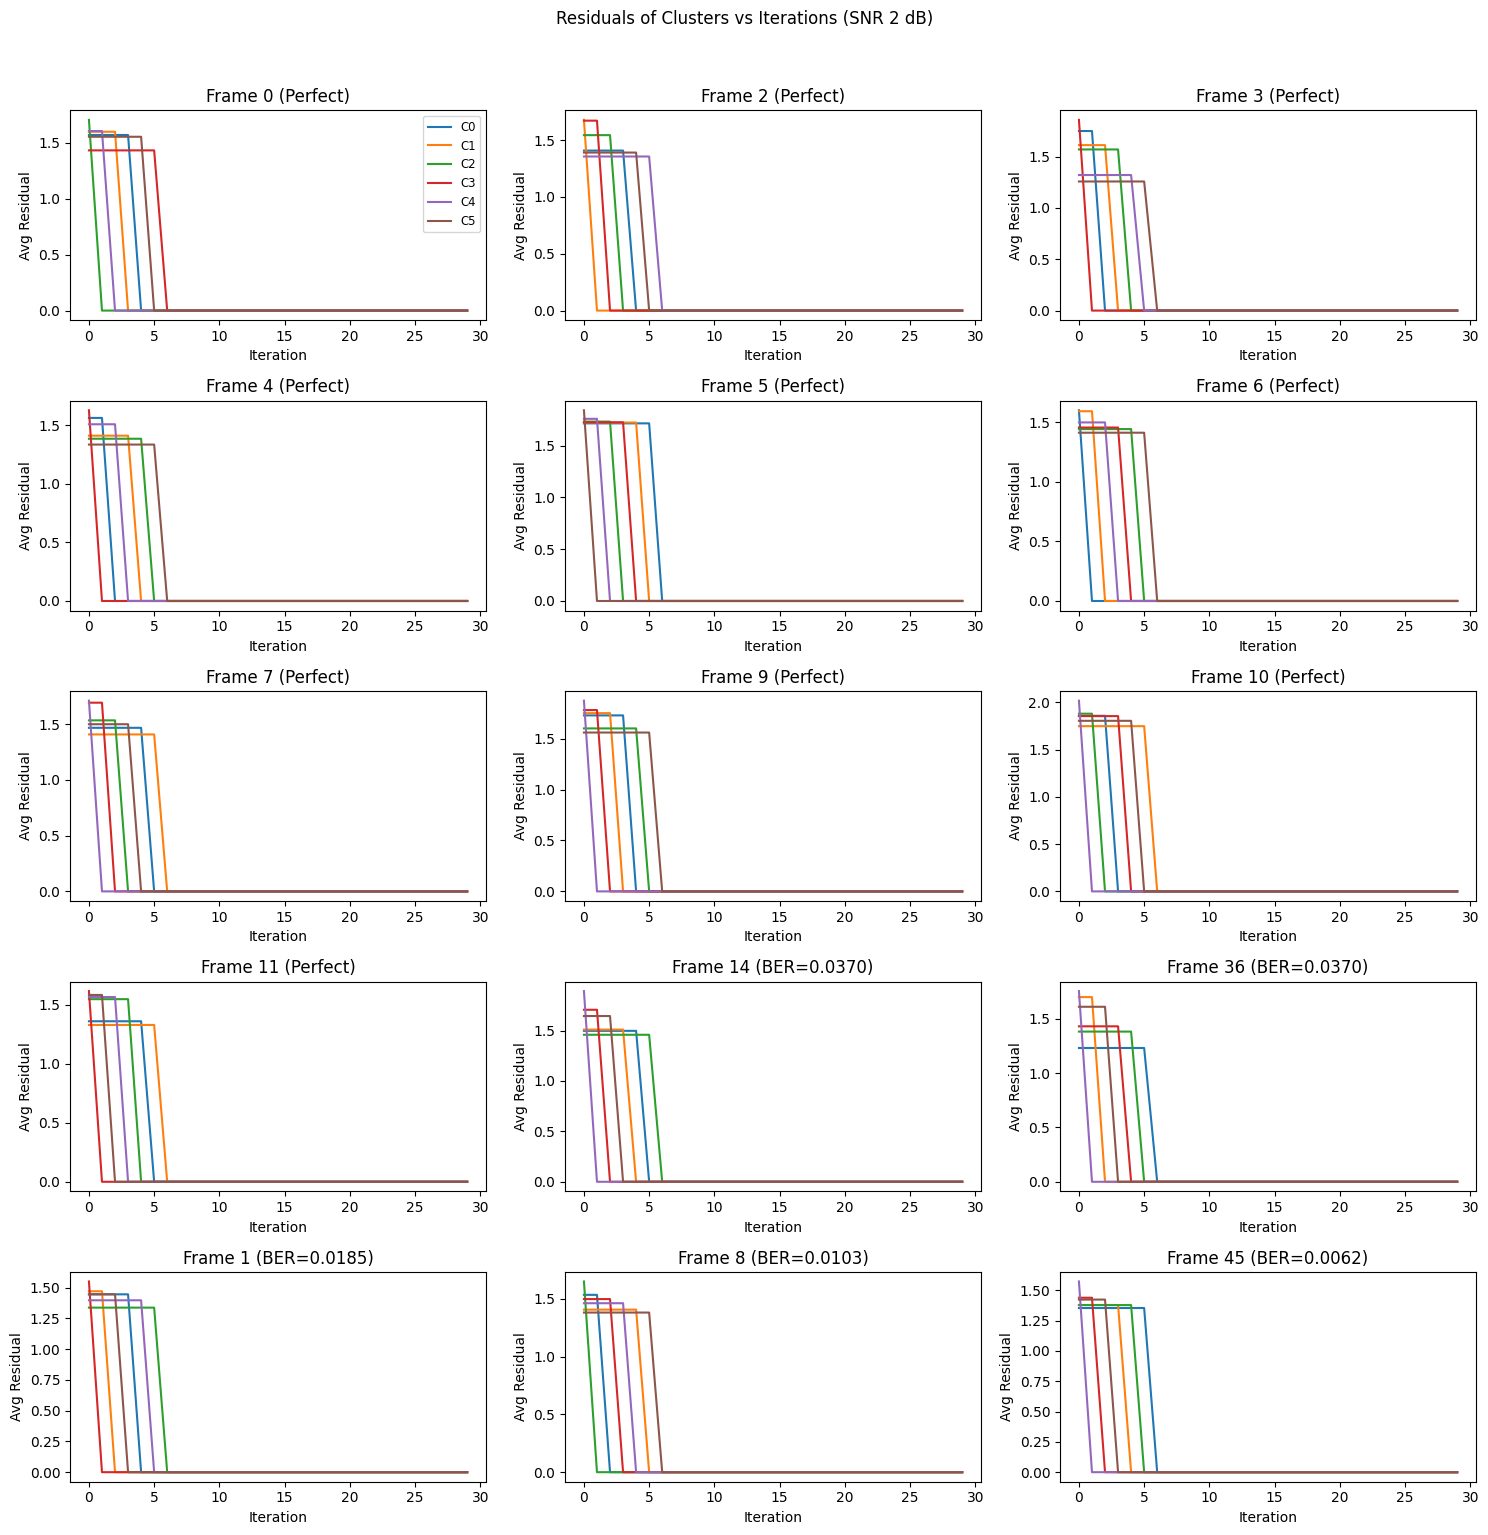

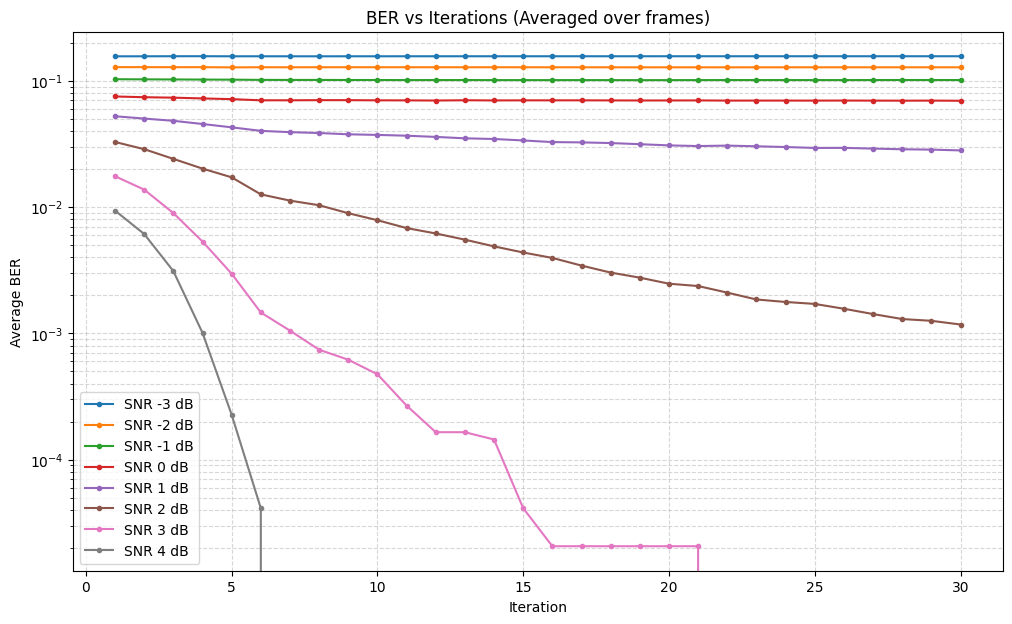

In [12]:
# Settings
snr_for_residuals = 2  # SNR to use for the residual plots
target_snrs = snrs # Use the snrs list defined in the previous cell

# Storage
avg_ber_vs_iter = {snr: np.zeros(max_iter) for snr in target_snrs}
frame_data_at_target_snr = []  # Stores info to select frames for Graph 1

print(f"Running simulation... Graph 1 will use frames from SNR {snr_for_residuals} dB")

for snr in target_snrs:
    rx_llrs = AWGNChannel(tx_codeword, snr_db=snr)
    ber_sum_at_iter = np.zeros(max_iter)
    
    for i in range(n_frames):
        llr = rx_llrs[i, :].copy()
        
        decoder.reset()
        decoder.initialise_log_domain_bp(llr)
        
        frame_res_history = [] # To store (iter, cluster) residuals
        
        for iter_num in range(max_iter):
            residuals = decoder.get_residuals()
            
            # --- Graph 1 Data Collection ---
            if snr == snr_for_residuals:
                # Calculate avg residual for each cluster
                # clusters is list/array of index arrays. residuals is 1D array.
                iter_cluster_res = [np.mean(residuals[c]) for c in clusters]
                frame_res_history.append(iter_cluster_res)
            
            # Decode step
            cluster_idx, scheduled_cluster = pick_max_avg_residual_cluster(residuals, clusters)
            llr = decoder.decode_cluster(scheduled_cluster)
            
            # --- Graph 2 Data Collection ---
            # Calculate BER at this iteration
            decoded_bits = (llr < 0).astype(int)
            # message[i] shape: (n,). decoded_bits shape might be n_codeword. Slice to n.
            current_ber_val = findBER(np.array([message[i]]), np.array([decoded_bits[:n]]))
            ber_sum_at_iter[iter_num] += current_ber_val
            
        # End of frame
        if snr == snr_for_residuals:
            final_ber = current_ber_val 
            frame_data_at_target_snr.append({
                'id': i,
                'final_ber': final_ber,
                'residuals': np.array(frame_res_history)
            })

    # Average BER
    avg_ber_vs_iter[snr] = ber_sum_at_iter / n_frames
    print(f"Completed SNR {snr} dB")

# ---------------------------------------------------------
# Graph 1: Residual of each cluster with iterations
# ---------------------------------------------------------

# Separate perfect and bad frames
perfect_frames = [f for f in frame_data_at_target_snr if f['final_ber'] == 0]
# Sort by highest BER for 'bad' frames
all_sorted_by_ber = sorted(frame_data_at_target_snr, key=lambda x: x['final_ber'], reverse=True)
bad_frames = [f for f in all_sorted_by_ber if f['final_ber'] > 0]

# Selection: up to 10 perfect, up to 5 bad
selected_perfect = perfect_frames[:10]
selected_bad = bad_frames[:5]
frames_to_plot = selected_perfect + selected_bad

if not frames_to_plot:
    print("No frames found to plot for Graph 1.")
else:
    num_plots = len(frames_to_plot)
    cols = 3
    rows = (num_plots + cols - 1) // cols
    
    plt.figure(figsize=(15, 3 * rows))
    
    for idx, frame_info in enumerate(frames_to_plot):
        plt.subplot(rows, cols, idx + 1)
        res_data = frame_info['residuals'] # Shape: (iters, n_clusters)
        
        # Plot line for each cluster
        for c_i in range(res_data.shape[1]):
            plt.plot(res_data[:, c_i], label=f'C{c_i}')
            
        status = "Perfect" if frame_info['final_ber'] == 0 else f"BER={frame_info['final_ber']:.4f}"
        plt.title(f"Frame {frame_info['id']} ({status})")
        plt.xlabel("Iteration")
        plt.ylabel("Avg Residual")
        if idx == 0:
            plt.legend(fontsize='small')
            
    plt.suptitle(f"Residuals of Clusters vs Iterations (SNR {snr_for_residuals} dB)", y=1.02)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Graph 2: BER vs number of iterations averaged across all frames
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))
iterations_x = np.arange(1, max_iter + 1)

for snr in target_snrs:
    plt.plot(iterations_x, avg_ber_vs_iter[snr], marker='.', label=f'SNR {snr} dB')

plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Average BER")
plt.title("BER vs Iterations (Averaged over frames)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()